In [1]:
import pandas as pd 
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.preprocessing import StandardScaler

In [2]:
data = pd.read_csv("Metro_Interstate_Traffic_Volume.csv")
data["date_time"] = pd.to_datetime(data["date_time"], format = "mixed")
data["holiday"] = data ["holiday"].fillna("noholiday")
data['day'] = data['date_time'].dt.day
data['month'] = data['date_time'].dt.month
data['year'] = data['date_time'].dt.year
data['day_of_week'] = data['date_time'].dt.day_name()
data['hours'] = data['date_time'].dt.hour
data

,traffic_volume,holiday,temp,rain_1h,snow_1h,clouds_all,weather_main,weather_description,date_time,day,month,year,day_of_week,hours
0,5545,noholiday,288.28,0.0,0.0,40,Clouds,scattered clouds,2012-02-10 09:00:00,10,2,2012,Friday,9
1,4516,noholiday,289.36,0.0,0.0,75,Clouds,broken clouds,2012-02-10 10:00:00,10,2,2012,Friday,10
2,4767,noholiday,289.58,0.0,0.0,90,Clouds,overcast clouds,2012-02-10 11:00:00,10,2,2012,Friday,11
3,5026,noholiday,290.13,0.0,0.0,90,Clouds,overcast clouds,2012-02-10 12:00:00,10,2,2012,Friday,12
4,4918,noholiday,291.14,0.0,0.0,75,Clouds,broken clouds,2012-02-10 13:00:00,10,2,2012,Friday,13
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
48199,3543,noholiday,283.45,0.0,0.0,75,Clouds,broken clouds,2018-09-30 19:00:00,30,9,2018,Sunday,19
48200,2781,noholiday,282.76,0.0,0.0,90,Clouds,overcast clouds,2018-09-30 20:00:00,30,9,2018,Sunday,20
48201,2159,noholiday,282.73,0.0,0.0,90,Thunderstorm,proximity thunderstorm,2018-09-30 21:00:00,30,9,2018,Sunday,21
48202,1450,noholiday,282.09,0.0,0.0,90,Clouds,overcast clouds,2018-09-30 22:00:00,30,9,2018,Sunday,22


In [3]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 48204 entries, 0 to 48203
Data columns (total 14 columns):
 #   Column               Non-Null Count  Dtype         
---  ------               --------------  -----         
 0   traffic_volume       48204 non-null  int64         
 1   holiday              48204 non-null  object        
 2   temp                 48204 non-null  float64       
 3   rain_1h              48204 non-null  float64       
 4   snow_1h              48204 non-null  float64       
 5   clouds_all           48204 non-null  int64         
 6   weather_main         48204 non-null  object        
 7   weather_description  48204 non-null  object        
 8   date_time            48204 non-null  datetime64[ns]
 9   day                  48204 non-null  int32         
 10  month                48204 non-null  int32         
 11  year                 48204 non-null  int32         
 12  day_of_week          48204 non-null  object        
 13  hours                48204 non-

In [4]:
categorical_columns = ['weather_main', 'holiday', 'day_of_week']

data_encoded = pd.get_dummies(data, columns=categorical_columns)
data_encoded

#convert the weather_desicption aswell
#convert data_time column into separate into three columns, day, month, year

,traffic_volume,temp,rain_1h,snow_1h,clouds_all,weather_description,date_time,day,month,year,...,holiday_Veterans Day,holiday_Washingtons Birthday,holiday_noholiday,day_of_week_Friday,day_of_week_Monday,day_of_week_Saturday,day_of_week_Sunday,day_of_week_Thursday,day_of_week_Tuesday,day_of_week_Wednesday
0,5545,288.28,0.0,0.0,40,scattered clouds,2012-02-10 09:00:00,10,2,2012,...,False,False,True,True,False,False,False,False,False,False
1,4516,289.36,0.0,0.0,75,broken clouds,2012-02-10 10:00:00,10,2,2012,...,False,False,True,True,False,False,False,False,False,False
2,4767,289.58,0.0,0.0,90,overcast clouds,2012-02-10 11:00:00,10,2,2012,...,False,False,True,True,False,False,False,False,False,False
3,5026,290.13,0.0,0.0,90,overcast clouds,2012-02-10 12:00:00,10,2,2012,...,False,False,True,True,False,False,False,False,False,False
4,4918,291.14,0.0,0.0,75,broken clouds,2012-02-10 13:00:00,10,2,2012,...,False,False,True,True,False,False,False,False,False,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
48199,3543,283.45,0.0,0.0,75,broken clouds,2018-09-30 19:00:00,30,9,2018,...,False,False,True,False,False,False,True,False,False,False
48200,2781,282.76,0.0,0.0,90,overcast clouds,2018-09-30 20:00:00,30,9,2018,...,False,False,True,False,False,False,True,False,False,False
48201,2159,282.73,0.0,0.0,90,proximity thunderstorm,2018-09-30 21:00:00,30,9,2018,...,False,False,True,False,False,False,True,False,False,False
48202,1450,282.09,0.0,0.0,90,overcast clouds,2018-09-30 22:00:00,30,9,2018,...,False,False,True,False,False,False,True,False,False,False


In [5]:
y = data_encoded["traffic_volume"]
X = data_encoded.drop(["date_time", "traffic_volume", 'day', 'month', 'year', 'weather_description'], axis=1)
#run the models, run expriments drop weather_description, drop weather_description and day_of_week

In [6]:
y

0        5545
1        4516
2        4767
3        5026
4        4918
         ... 
48199    3543
48200    2781
48201    2159
48202    1450
48203     954
Name: traffic_volume, Length: 48204, dtype: int64

In [7]:
X

,temp,rain_1h,snow_1h,clouds_all,hours,weather_main_Clear,weather_main_Clouds,weather_main_Drizzle,weather_main_Fog,weather_main_Haze,...,holiday_Veterans Day,holiday_Washingtons Birthday,holiday_noholiday,day_of_week_Friday,day_of_week_Monday,day_of_week_Saturday,day_of_week_Sunday,day_of_week_Thursday,day_of_week_Tuesday,day_of_week_Wednesday
0,288.28,0.0,0.0,40,9,False,True,False,False,False,...,False,False,True,True,False,False,False,False,False,False
1,289.36,0.0,0.0,75,10,False,True,False,False,False,...,False,False,True,True,False,False,False,False,False,False
2,289.58,0.0,0.0,90,11,False,True,False,False,False,...,False,False,True,True,False,False,False,False,False,False
3,290.13,0.0,0.0,90,12,False,True,False,False,False,...,False,False,True,True,False,False,False,False,False,False
4,291.14,0.0,0.0,75,13,False,True,False,False,False,...,False,False,True,True,False,False,False,False,False,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
48199,283.45,0.0,0.0,75,19,False,True,False,False,False,...,False,False,True,False,False,False,True,False,False,False
48200,282.76,0.0,0.0,90,20,False,True,False,False,False,...,False,False,True,False,False,False,True,False,False,False
48201,282.73,0.0,0.0,90,21,False,False,False,False,False,...,False,False,True,False,False,False,True,False,False,False
48202,282.09,0.0,0.0,90,22,False,True,False,False,False,...,False,False,True,False,False,False,True,False,False,False


In [8]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print("Training features shape:", X_train.shape)
print("Testing features shape:", X_test.shape)
print("Training target shape:", y_train.shape)
print("Testing target shape:", y_test.shape)

Training features shape: (38563, 35)
Testing features shape: (9641, 35)
Training target shape: (38563,)
Testing target shape: (9641,)


### linear regression model

train R-squared: 0.1643200417433136
train Mean Squared Error: 3297573.888136436
test R-squared: 0.1673127216257324
test Mean Squared Error: 3292040.4455273314


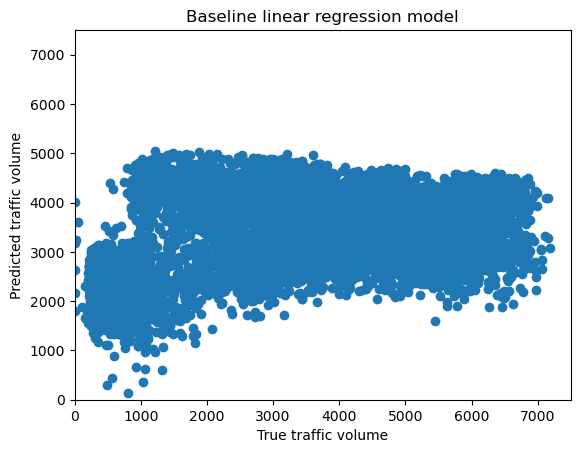

In [9]:
#intialize linear regression model
model = LinearRegression()
#train the model
model.fit(X_train, y_train)
#test the model, predictions
y_pred = model.predict(X_test)
#train and test the accuracy(r Squared or mse)
r2_train = r2_score(y_train, model.predict(X_train))
print(f"train R-squared: {r2_train}")

mse_train = mean_squared_error(y_train, model.predict(X_train))
print(f"train Mean Squared Error: {mse_train}")

r2_test = r2_score(y_test, model.predict(X_test))
print(f"test R-squared: {r2_test}")

mse_test = mean_squared_error(y_test, model.predict(X_test))
print(f"test Mean Squared Error: {mse_test}")

plot = plt.scatter(y_test, y_pred) 
plt.xlim([0,7500])
plt.ylim([0,7500])
plt.xlabel("True traffic volume")
plt.ylabel("Predicted traffic volume")
plt.title("Baseline linear regression model")
plot.figure.savefig('linear_regression_baseline.pdf', format='pdf')

### Decision tree model

train R-squared: 0.9995278238806202
train Mean Squared Error: 1863.19610334604
test R-squared: 0.7584980433255575
test Mean Squared Error: 954781.2602571195


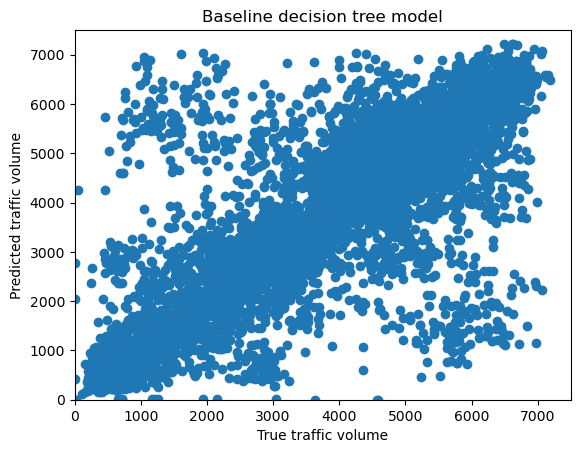

In [10]:
#intialize decision tree model
model = DecisionTreeRegressor(random_state=42)
#train the model
model.fit(X_train, y_train)
#test the model, predictions
y_pred = model.predict(X_test)
#train and test the accuracy(r Squared or mse)
r2_train = r2_score(y_train, model.predict(X_train))
print(f"train R-squared: {r2_train}")

mse_train = mean_squared_error(y_train, model.predict(X_train))
print(f"train Mean Squared Error: {mse_train}")

r2_test = r2_score(y_test, model.predict(X_test))
print(f"test R-squared: {r2_test}")

mse_test = mean_squared_error(y_test, model.predict(X_test))
print(f"test Mean Squared Error: {mse_test}")

plot1 = plt.scatter(y_test, y_pred) 
plt.xlim([0,7500])
plt.ylim([0,7500])
plt.xlabel("True traffic volume")
plt.ylabel("Predicted traffic volume")
plt.title("Baseline decision tree model")
plot1.figure.savefig('decision_tree_baseline.pdf', format='pdf')

### Random Forest model

train R-squared: 0.9784767290168263
train Mean Squared Error: 84930.33209682144
test R-squared: 0.8496247015211695
test Mean Squared Error: 594510.7814869825


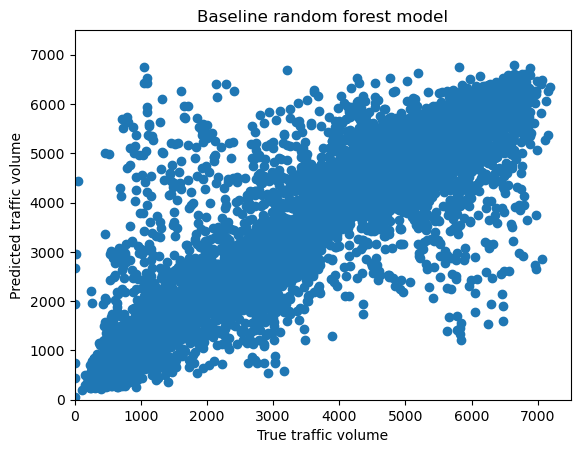

In [11]:
#intialize random forest model
model = RandomForestRegressor(n_estimators=100, random_state=42)
#train the model
model.fit(X_train, y_train)
#test the mode, predictions
y_pred = model.predict(X_test)
#train and test the accuracy(r Sqaured or mse)
r2_train = r2_score(y_train, model.predict(X_train))
print(f"train R-squared: {r2_train}")

mse_train = mean_squared_error(y_train, model.predict(X_train))
print(f"train Mean Squared Error: {mse_train}")

r2_test = r2_score(y_test, model.predict(X_test))
print(f"test R-squared: {r2_test}")

mse_test = mean_squared_error(y_test, model.predict(X_test))
print(f"test Mean Squared Error: {mse_test}")

plot = plt.scatter(y_test, y_pred) 
plt.xlim([0,7500])
plt.ylim([0,7500])
plt.xlabel("True traffic volume")
plt.ylabel("Predicted traffic volume")
plt.title("Baseline random forest model")
plot.figure.savefig('random_forest_baseline.pdf', format='pdf')

### Hyperparameter tuning of random forest model

In [12]:
#try estimated 500, 1000
#try different range for min sample
#max feature column change to 5


In [13]:
param_grid = {
    'n_estimators': [500, 1000],
    'max_features': range(1, 5),
    #'max_depth': [None, 10, 20, 30],
    'min_samples_split': range(20, 150, 10),
   
}
# Initialize the model
model = RandomForestRegressor(random_state=42)

# Initialize GridSearchCV
grid_search = GridSearchCV(estimator=model, param_grid=param_grid, cv=5, verbose=5, scoring='r2')

# Fit the model
grid_search.fit(X_train, y_train)

# Get the best parameters
best_params = grid_search.best_params_
print(f"Best parameters: {best_params}")

# Train the model with the best parameters
best_model = grid_search.best_estimator_
best_model.fit(X_train, y_train)

# Predictions
y_pred_train = best_model.predict(X_train)
y_pred_test = best_model.predict(X_test)

# Evaluate the model
r2_train = r2_score(y_train, y_pred_train)
print(f"Train R-squared: {r2_train}")

mse_train = mean_squared_error(y_train, y_pred_train)
print(f"Train Mean Squared Error: {mse_train}")

r2_test = r2_score(y_test, y_pred_test)
print(f"Test R-squared: {r2_test}")

mse_test = mean_squared_error(y_test, y_pred_test)
print(f"Test Mean Squared Error: {mse_test}")

Fitting 5 folds for each of 104 candidates, totalling 520 fits
[CV 1/5] END max_features=1, min_samples_split=20, n_estimators=500;, score=0.818 total time=   8.9s
[CV 2/5] END max_features=1, min_samples_split=20, n_estimators=500;, score=0.808 total time=   8.9s
[CV 3/5] END max_features=1, min_samples_split=20, n_estimators=500;, score=0.821 total time=   9.2s
[CV 4/5] END max_features=1, min_samples_split=20, n_estimators=500;, score=0.810 total time=   9.0s
[CV 5/5] END max_features=1, min_samples_split=20, n_estimators=500;, score=0.812 total time=   8.9s
[CV 1/5] END max_features=1, min_samples_split=20, n_estimators=1000;, score=0.818 total time=  17.7s
[CV 2/5] END max_features=1, min_samples_split=20, n_estimators=1000;, score=0.808 total time=  18.0s
[CV 3/5] END max_features=1, min_samples_split=20, n_estimators=1000;, score=0.821 total time=  17.5s
[CV 4/5] END max_features=1, min_samples_split=20, n_estimators=1000;, score=0.810 total time=  18.0s
[CV 5/5] END max_feature

train R-squared: 0.881847303592374
train Mean Squared Error: 466227.82159270707
test R-squared: 0.8373968537455689
test Mean Squared Error: 642853.7434662043


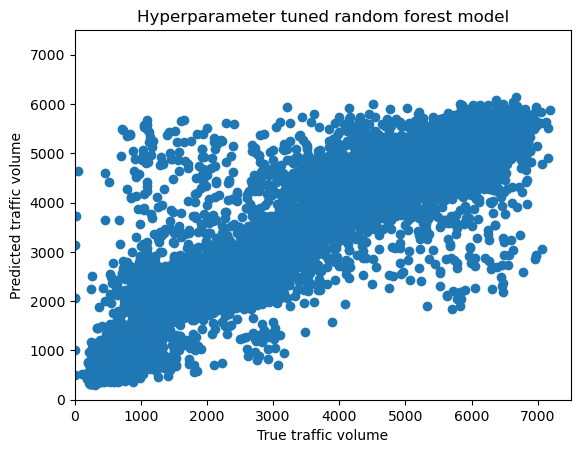

In [15]:
y_pred = best_model.predict(X_test)
#train and test the accuracy(r Sqaured or mse)
r2_train = r2_score(y_train, best_model.predict(X_train))
print(f"train R-squared: {r2_train}")

mse_train = mean_squared_error(y_train, best_model.predict(X_train))
print(f"train Mean Squared Error: {mse_train}")

r2_test = r2_score(y_test, best_model.predict(X_test))
print(f"test R-squared: {r2_test}")

mse_test = mean_squared_error(y_test, best_model.predict(X_test))
print(f"test Mean Squared Error: {mse_test}")

plot = plt.scatter(y_test, y_pred) 
plt.xlim([0,7500])
plt.ylim([0,7500])
plt.xlabel("True traffic volume")
plt.ylabel("Predicted traffic volume")
plt.title("Hyperparameter tuned random forest model")
plot.figure.savefig('random_forest_tuned.pdf', format='pdf')